In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import files

: 

In [44]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
data = pd.read_csv('/content/drive/MyDrive/1 2026 pachequito/primerdataset')
print(data.head())

      UID  BLOCKID  SUMLEVEL  COUNTYID  STATEID        state state_ab  \
0  267822      NaN       140        53       36     New York       NY   
1  246444      NaN       140       141       18      Indiana       IN   
2  245683      NaN       140        63       18      Indiana       IN   
3  279653      NaN       140       127       72  Puerto Rico       PR   
4  247218      NaN       140       161       20       Kansas       KS   

         city           place   type  ... female_age_mean  female_age_median  \
0    Hamilton        Hamilton   City  ...        44.48629           45.33333   
1  South Bend        Roseland   City  ...        36.48391           37.58333   
2    Danville        Danville   City  ...        42.15810           42.83333   
3    San Juan        Guaynabo  Urban  ...        47.77526           50.58333   
4   Manhattan  Manhattan City   City  ...        24.17693           21.58333   

   female_age_stdev  female_age_sample_weight  female_age_samples  pct_own  \
0 

In [46]:
# Seleccionar las columnas de interés
columns_X = [
    'ALand', 'AWater', 'pop', 'male_pop', 'female_pop',
    'rent_median', 'rent_stdev', 'rent_sample_weight', 'rent_samples',
    'rent_gt_10', 'rent_gt_15', 'rent_gt_20', 'rent_gt_25', 'rent_gt_30',
    'rent_gt_35', 'rent_gt_40', 'male_age_mean', 'female_age_mean'
]
column_y = 'rent_mean'


In [47]:
# Filtrar el dataset para las columnas seleccionadas y eliminar filas con valores faltantes
data_selected = data[columns_X + [column_y]].dropna()

In [48]:
# Mostrar las primeras filas del dataset seleccionado
print("Primeras filas del dataset seleccionado:")
display(data_selected.head())

Primeras filas del dataset seleccionado:


,ALand,AWater,pop,male_pop,female_pop,rent_median,rent_stdev,rent_sample_weight,rent_samples,rent_gt_10,rent_gt_15,rent_gt_20,rent_gt_25,rent_gt_30,rent_gt_35,rent_gt_40,male_age_mean,female_age_mean,rent_mean
0,202183361.0,1699120,5230,2612,2618,784.0,232.63967,272.34441,362.0,0.86761,0.79155,0.59155,0.45634,0.42817,0.18592,0.15493,42.48574,44.48629,769.38638
1,1560828.0,100363,2633,1349,1284,848.0,253.46747,312.58622,513.0,0.97410,0.93227,0.69920,0.69920,0.55179,0.41235,0.39044,34.84728,36.48391,804.87924
2,69561595.0,284193,6881,3643,3238,703.0,323.39011,291.85520,378.0,0.95238,0.88624,0.79630,0.66667,0.39153,0.39153,0.28307,39.38154,42.15810,742.77365
3,1105793.0,0,2700,1141,1559,782.0,297.39258,259.30316,368.0,0.94693,0.87151,0.69832,0.61732,0.51397,0.46927,0.35754,48.64749,47.77526,803.42018
4,2554403.0,0,5637,2586,3051,881.0,392.44096,1005.42886,1704.0,0.99286,0.98247,0.91688,0.84740,0.78247,0.60974,0.55455,26.07533,24.17693,938.56493


In [49]:
# Separar las características (X) y la variable objetivo (y)
X = data_selected[columns_X].values
y = data_selected[column_y].values

In [50]:
# Normalizar las características
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizarCaracteristicas(X)

In [51]:
# Mostrar los valores de media y desviación estándar
print("\nMedia calculada para cada característica:")
print(mu)
print("\nDesviación estándar calculada para cada característica:")
print(sigma)


Media calculada para cada característica:
[1.30267321e+08 6.42997161e+06 4.35750909e+03 2.14178916e+03
 2.21571994e+03 1.00769990e+03 3.94328392e+02 2.96043835e+02
 5.48125477e+02 9.57851436e-01 8.67141107e-01 7.39408037e-01
 6.13000890e-01 5.00010491e-01 4.11061712e-01 3.45463835e-01
 3.83470544e+01 4.03260328e+01]

Desviación estándar calculada para cada característica:
[1.28258674e+09 2.19585902e+08 2.14069682e+03 1.09951494e+03
 1.08492083e+03 4.43724395e+02 1.87142824e+02 2.72194389e+02
 4.61520301e+02 6.29198729e-02 1.09522824e-01 1.43698302e-01
 1.60154863e-01 1.63880079e-01 1.60077964e-01 1.53107202e-01
 5.54363713e+00 5.79612524e+00]


In [52]:
# Añadir una columna de unos a X para el término de intercepción
X_ready = np.concatenate([np.ones((X_norm.shape[0], 1)), X_norm], axis=1)

In [53]:
# Función para calcular el costo
def calcularCosto(X, y, theta):
    m = y.size
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [54]:
# Función para el descenso de gradiente
def descensoGradiente(X, y, theta, alpha, num_iteraciones):
    m = y.shape[0]
    theta = theta.copy()
    J_historico = []

    for i in range(num_iteraciones):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_historico.append(calcularCosto(X, y, theta))

    return theta, J_historico


In [55]:
# Inicializar theta
theta = np.zeros(X_ready.shape[1])

In [56]:
# Parámetros para el descenso de gradiente
alpha = 0.01
num_iteraciones = 1000

In [57]:
# Ejecutar el descenso de gradiente
theta_optimo, J_historico = descensoGradiente(X_ready, y, theta, alpha, num_iteraciones)

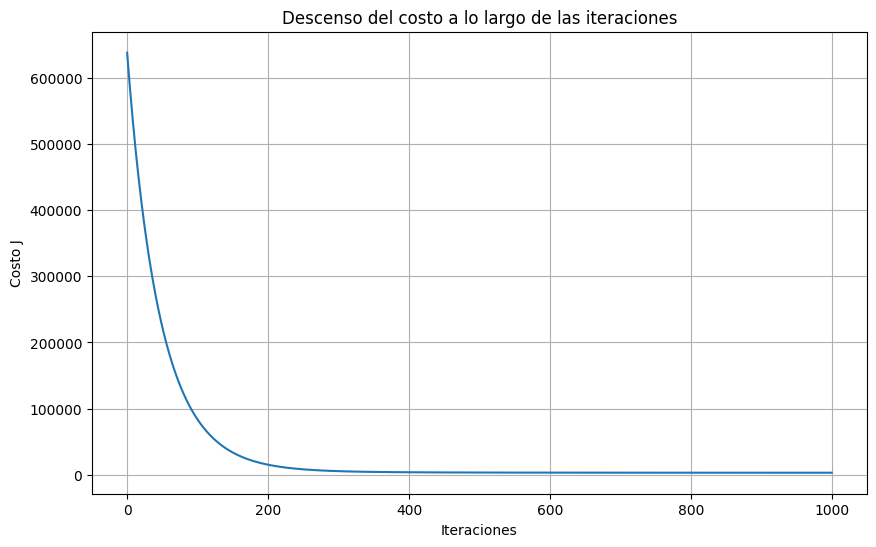

In [58]:
# Graficar el costo a lo largo de las iteraciones
plt.figure(figsize=(10, 6))
plt.plot(J_historico)
plt.xlabel('Iteraciones')
plt.ylabel('Costo J')
plt.title('Descenso del costo a lo largo de las iteraciones')
plt.grid(True)
plt.show()

In [59]:
# Mostrar los valores óptimos de theta
print("\nValores óptimos de theta:")
print(theta_optimo)


Valores óptimos de theta:
[ 1.05512330e+03 -2.51831974e+00  1.94295005e-01  8.65617638e-01
 -2.44218436e-01  1.95548531e+00  3.68802089e+02  6.77912331e+01
 -4.31474413e+01  3.05592507e+01  7.90473365e+00  3.35865188e+00
 -2.13025896e+00 -3.93302808e+00 -1.23841793e+00  2.24844320e+00
 -1.16438544e+00  5.50523840e+00 -5.51384947e+00]


In [60]:
# Predecir los valores de y para el conjunto de entrenamiento
y_pred = np.dot(X_ready, theta_optimo)

In [70]:
# Calcular las métricas de error
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nMétricas de error:")
print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse}')
print(f'Error Absoluto Medio (MAE): {mae}')
print(f'Coeficiente de Determinación (R²): {r2}')


Métricas de error:
Error Cuadrático Medio (MSE): 5880.301081617154
Raíz del Error Cuadrático Medio (RMSE): 76.68312123027566
Error Absoluto Medio (MAE): 52.78202141333894
Coeficiente de Determinación (R²): 0.9692572074795415


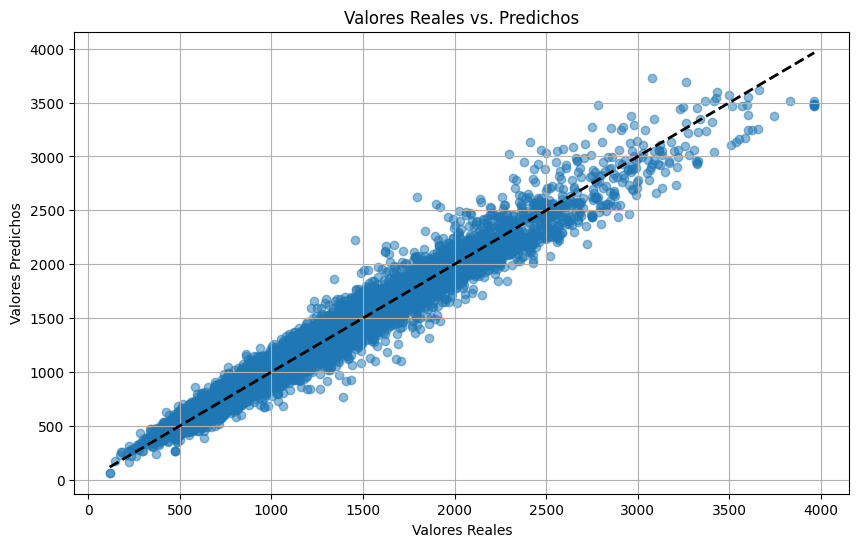

In [63]:
# Graficar los valores reales vs. predichos
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

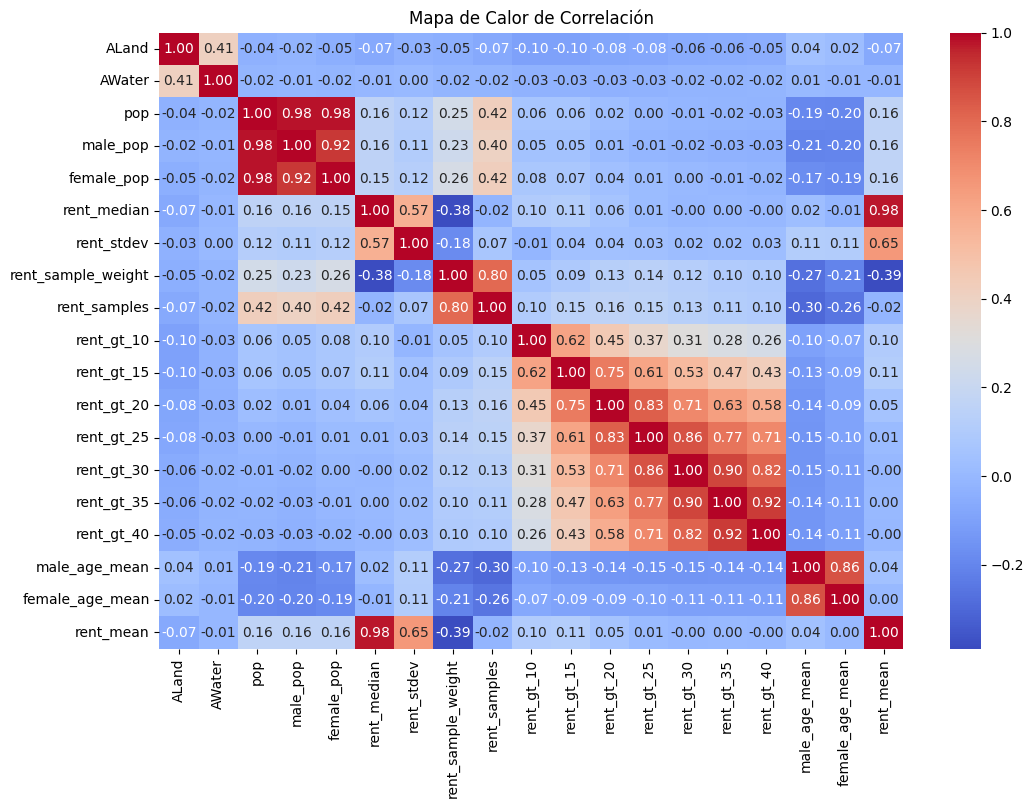

In [64]:
# Mapa de calor de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(data_selected.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación')
plt.show()

In [69]:
# Función para predecir un nuevo valor
def predecir_nuevo_valor(X_new, mu, sigma, theta_optimo):
    # Normalizar el nuevo valor usando mu y sigma del entrenamiento
    X_new_norm = (X_new - mu) / sigma

    # Añadir el término de intercepción
    X_new_ready = np.concatenate([np.ones((X_new_norm.shape[0], 1)), X_new_norm], axis=1)

    # Predecir usando theta_optimo
    y_pred = np.dot(X_new_ready, theta_optimo)

    return y_pred

# Ejemplo de uso: Ingresa los valores para las 19 características
# Asegúrate de que los valores estén en el mismo orden que las columnas seleccionadas
nuevos_valores = np.array([
    [1500, 200, 5000, 2500, 2500,  # ALand, AWater, pop, male_pop, female_pop
     1200, 100, 5000, 100, 0.1,  # rent_median, rent_stdev, rent_sample_weight, rent_samples, rent_gt_10
     0.05, 0.03, 0.02, 0.04, 0.01,  # rent_gt_15, rent_gt_20, rent_gt_25, rent_gt_30, rent_gt_35
     0.005, 35, 34]  # rent_gt_40, male_age_mean, female_age_mean
])

# Predecir el valor de rent_mean
prediccion = predecir_nuevo_valor(nuevos_valores, mu, sigma, theta_optimo)

print(f"\nEl valor predicho de 'rent_mean' para los nuevos valores es: {prediccion[0]}")



El valor predicho de 'rent_mean' para los nuevos valores es: 229.32219933687117
